# Shor's algorithm on a simulator

Factor 15 with a = 7, look at what the counting register measures, then factor a few other small numbers. The code lives in `src/shors.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from fractions import Fraction

from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

from src.shors import factor, order_finding_circuit

## The order-finding circuit

Eight counting qubits and four work qubits. Counting qubit j controls multiplication by 7^(2^j) mod 15, and the work register starts in |1>.

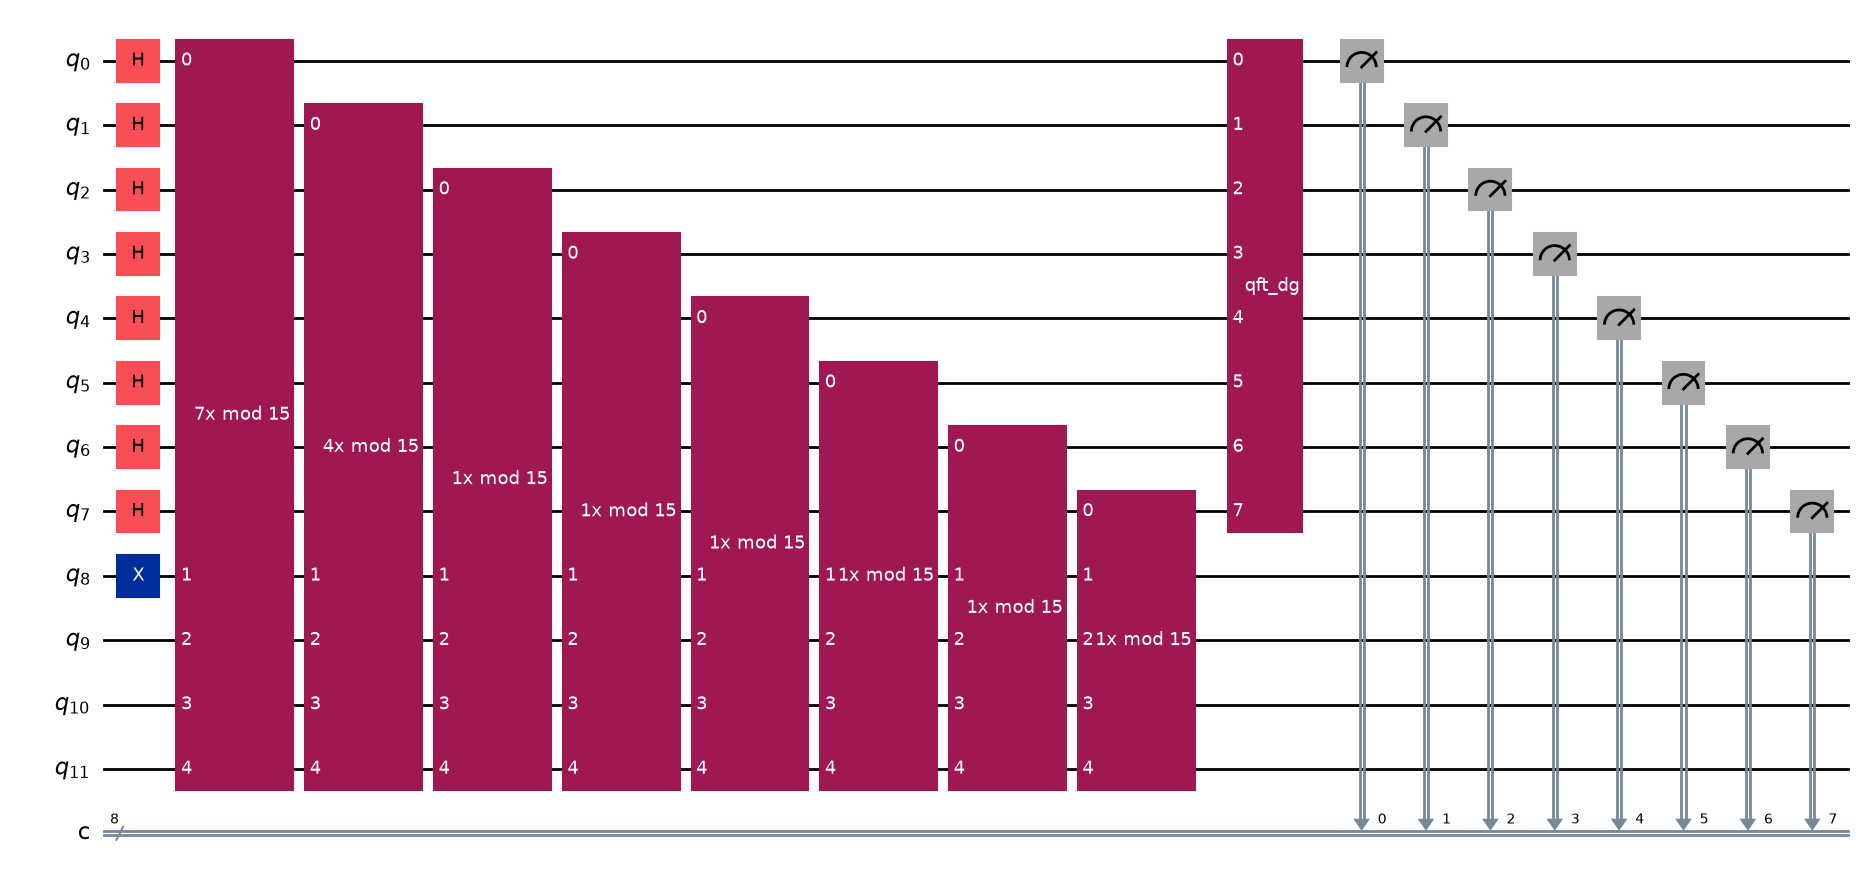

In [2]:
a, n = 7, 15
qc = order_finding_circuit(a, n)
qc.draw("mpl", fold=-1)

## What the counting register reads

7 has order 4 mod 15, so the readings land on multiples of 256 / 4 = 64.

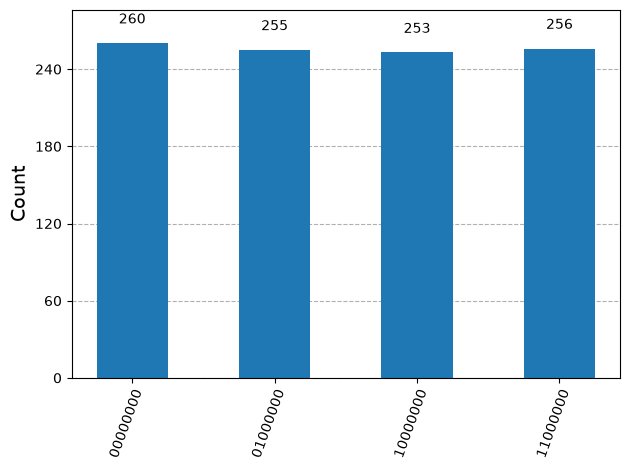

In [3]:
backend = AerSimulator()
counts = backend.run(transpile(qc, backend), shots=1024, seed_simulator=7).result().get_counts()
plot_histogram(counts)

In [4]:
print("reading  phase  fraction  guess for r")
for bits in sorted(counts):
    y = int(bits, 2)
    frac = Fraction(y, 2**8).limit_denominator(n)
    print(f"{y:7d}  {y / 256:.3f}  {str(frac):>8}  {frac.denominator:11d}")

reading  phase  fraction  guess for r
      0  0.000         0            1
     64  0.250       1/4            4
    128  0.500       1/2            2
    192  0.750       3/4            4


Readings of 0 and 128 give 1 and 2, which only divide the order. `order_from_counts` handles that by also trying the lcm of the denominators it has seen.

## Factoring

In [5]:
for n, a in [(15, 7), (21, 2), (33, None), (35, None)]:
    result = factor(n, a=a, seed=5)
    p, q = result.factors
    print(f"{n} = {p} x {q}  via {result.method}, a={result.a}, r={result.order}")

15 = 3 x 5  via order finding, a=7, r=4


21 = 7 x 3  via order finding, a=2, r=6
33 = 3 x 11  via gcd, a=21, r=None


35 = 7 x 5  via order finding, a=18, r=12
